# ĐỒ ÁN: PHÂN LOẠI RÁC THẢI VỚI HYBRID MODEL
---
**Dữ liệu:** TrashBox Dataset  
**Mô hình:** Hybrid (MobileNetV4 + Transformer Bridge)  
**Mục tiêu:** Phân loại 7 loại rác thải và giải thích quyết định của mô hình (XAI).

### 1. Cấu hình & Khởi tạo (Setup)
Thiết lập thư viện, seed và các thông số kỹ thuật.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import time
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler

def install_libs():
    libs = []
    try:
        import timm
    except ImportError:
        libs.append("timm")

    try:
        import pytorch_grad_cam
    except ImportError:
        libs.append("grad-cam")
    if libs:
        print(f"Installing missing libraries: {', '.join(libs)}...")
        os.system(f'pip install {" ".join(libs)}')
        print("Installation complete.")
    else:
        print("All libraries already installed.")

install_libs()

import timm
from timm.data.mixup import Mixup
from timm.scheduler import CosineLRScheduler
from timm.loss import SoftTargetCrossEntropy

warnings.filterwarnings("ignore")

CONFIG = {
    "num_classes": 7,
    "img_size": 384,
    "batch_size": 16,
    "num_workers": 2,

    "epochs": 30,
    "lr": 1e-4,
    "weight_decay": 0.05,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    "backbone_name": "mobilenetv4_conv_medium.e500_r256_in1k",
    "embed_dim": 256,
    "use_arcface": False,

    "arcface_s": 30.0,
    "arcface_m": 0.50,
}

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CONFIG['seed'])

print("-" * 50)
print(f"Setup Done!")
print(f"Device: {CONFIG['device']}")
print(f"Backbone: {CONFIG['backbone_name']}")
print("-" * 50)

Installing missing libraries: grad-cam...
Installation complete.
--------------------------------------------------
Setup Done!
Device: cuda
Backbone: mobilenetv4_conv_medium.e500_r256_in1k
--------------------------------------------------


### 2. Chuẩn bị Dữ liệu (Data Pipeline)
Sao chép dữ liệu từ Drive (nếu có) và khởi tạo DataLoader.

In [ ]:
DRIVE_TRAIN = '/content/drive/MyDrive/Data/TrashBox_train_set'
DRIVE_VAL = '/content/drive/MyDrive/Data/TrashBox_testandvalid_set'
LOCAL_TRAIN = '/content/temp_data/train'
LOCAL_VAL = '/content/temp_data/val'

def copy_data(src, dst):
    if os.path.exists(dst):
        return
    if os.path.exists(src):
        print(f"Copying {src} -> {dst}...")
        shutil.copytree(src, dst)

copy_data(DRIVE_TRAIN, LOCAL_TRAIN)
copy_data(DRIVE_VAL, LOCAL_VAL)

ROOT_TRAIN = LOCAL_TRAIN if os.path.exists(LOCAL_TRAIN) else DRIVE_TRAIN
ROOT_VAL = LOCAL_VAL if os.path.exists(LOCAL_VAL) else DRIVE_VAL

class SafeImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except Exception:
            return self.__getitem__(random.randint(0, len(self)-1))

train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(CONFIG['img_size'], scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25)
])

val_tfm = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Init DataLoaders...")
train_ds = SafeImageFolder(ROOT_TRAIN, transform=train_tfm)
val_ds = SafeImageFolder(ROOT_VAL, transform=val_tfm)

CONFIG['num_classes'] = len(train_ds.classes)
class_names = train_ds.classes

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

mixup_fn = Mixup(
    mixup_alpha=0.8,
    cutmix_alpha=1.0,
    prob=1.0,
    switch_prob=0.5,
    mode='batch',
    label_smoothing=0.1,
    num_classes=CONFIG['num_classes']
)

print(f"Classes: {class_names}")

Copying /content/drive/MyDrive/Data/TrashBox_train_set -> /content/temp_data/train...
Copying /content/drive/MyDrive/Data/TrashBox_testandvalid_set -> /content/temp_data/val...
Init DataLoaders...
Classes: ['cardboard', 'e-waste', 'glass', 'medical', 'metal', 'paper', 'plastic']


In [ ]:
from collections import Counter

def plot_data_distribution_from_targets(targets, class_names, title="Data Distribution"):
    label_counts = Counter(targets)
    names = [class_names[i] for i in sorted(label_counts.keys())]
    values = [label_counts[i] for i in sorted(label_counts.keys())]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(names, values, edgecolor='black')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

Checking Data Distribution:


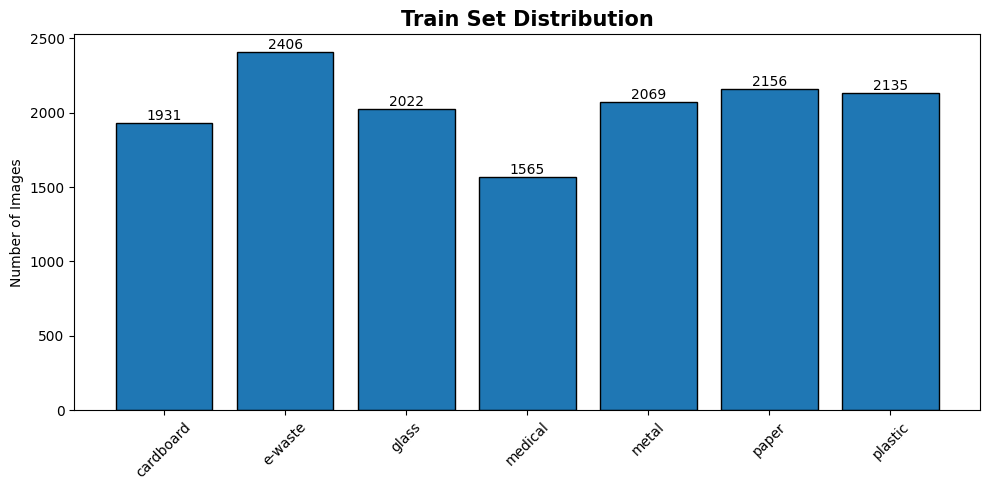

In [ ]:
print("Checking Data Distribution:")
plot_data_distribution_from_targets(
    targets=train_ds.targets,
    class_names=class_names,
    title="Train Set Distribution"
)

### 3. Kiến trúc Mô hình (Proposed Architecture)
Mô hình Hybrid: **Encoder (MobileNetV4)** + **Bridge** + **Decoder/Refiner (Transformer)**.

In [ ]:
import math
import torch.nn.functional as F

class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50, easy_margin=False):
        super(ArcMarginProduct, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.easy_margin = easy_margin
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m

        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.att = nn.Sequential(
            nn.Linear(dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        weights = F.softmax(self.att(x), dim=1)
        context = torch.sum(x * weights, dim=1)
        return context, weights

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)), nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim), nn.Dropout(drop)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class HybridTrashModel(nn.Module):
    def __init__(self, num_classes, backbone_name=CONFIG['backbone_name'], embed_dim=CONFIG['embed_dim'], use_arcface=CONFIG['use_arcface']):
        super().__init__()
        self.use_arcface = use_arcface

        # 1. Backbone (MobileNetV4)
        print(f"Loading backbone: {backbone_name}...")
        self.backbone = timm.create_model(backbone_name, pretrained=True, features_only=True)
        last_channel = self.backbone.feature_info[-1]['num_chs']

        # 2. Bridge (Conv projection)
        self.proj = nn.Conv2d(last_channel, embed_dim, kernel_size=1)

        # 3. Transformer Refiner
        self.transformer = nn.Sequential(
            TransformerBlock(embed_dim, num_heads=4, drop=0.1),
            TransformerBlock(embed_dim, num_heads=4, drop=0.1)
        )

        # 4. Attention Pooling
        self.pool = AttentionPooling(embed_dim)
        self.norm = nn.LayerNorm(embed_dim)

        # 5. Classifier Head
        if self.use_arcface:
            self.head = ArcMarginProduct(embed_dim, num_classes, s=CONFIG['arcface_s'], m=CONFIG['arcface_m'])
        else:
            self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x, labels=None):
        # Backbone Feature Extraction
        features = self.backbone(x)[-1] # [B, C, H, W]

        # Bridge & Flatten
        x = self.proj(features)
        x = x.flatten(2).transpose(1, 2) # [B, N, C]

        # Transformer
        x = self.transformer(x)
        x = self.norm(x)

        # Attention Pooling (Return weights for XAI)
        x_pool, attn_weights = self.pool(x)

        # Classification
        if self.use_arcface and labels is not None:
            logits = self.head(x_pool, labels)
        else:
            logits = self.head(x_pool)

        return logits, attn_weights

# Initialize
model = HybridTrashModel(num_classes=CONFIG['num_classes']).to(CONFIG['device'])
print("Hybrid Model Initialized with Attention Pooling & Optional ArcFace.")

Loading backbone: mobilenetv4_conv_medium.e500_r256_in1k...


model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Hybrid Model Initialized with Attention Pooling & Optional ArcFace.


### 4. Thiết lập XAI (Explainable AI)
Chuẩn bị Class Grad-CAM để giải thích mô hình sau khi train.

In [ ]:
import cv2

class GradCAM_ResNet_MobileNet:
    """
    Grad-CAM implementation specifically tailored for the CNN Backbone part
    of the Hybrid Model.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.handle_f = target_layer.register_forward_hook(self.save_activation)
        self.handle_b = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.handle_f.remove()
        self.handle_b.remove()

    def __call__(self, x, class_idx=None):
        # Reset gradients
        self.model.zero_grad()

        # Forward pass
        logits, _ = self.model(x)

        if class_idx is None:
            class_idx = torch.argmax(logits, dim=1).item()

        # Backward pass focusing on the target class
        score = logits[0, class_idx]
        score.backward()

        # Generate Heatmap
        gradients = self.gradients
        activations = self.activations

        # Global Average Pooling of gradients
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)

        # Weighted combination of activations
        cam = torch.sum(weights * activations, dim=1, keepdim=True)

        # ReLU and Normalization
        cam = F.relu(cam)
        cam = cam.view(cam.size(2), cam.size(3)).cpu().detach().numpy()

        # Scale to [0, 1]
        cam = cam - np.min(cam)
        if np.max(cam) > 0:
            cam = cam / np.max(cam)

        return cam

# Helper to Visualize Attention Map from the Transformer Pooling
def visualize_attention_pooling(img_tensor, attn_weights, alpha=0.6):
    """
    Overlays the Attention Pooling weights onto the original image.
    This shows exactly which 'tokens' (patches) the Transformer focused on.
    """
    # attn_weights shape: [B, N, 1] -> [N]
    w = attn_weights[0].squeeze().cpu().detach().numpy()

    # Reshape to 2D grid (H/32, W/32) approx
    grid_size = int(np.sqrt(w.shape[0]))
    w_2d = w.reshape(grid_size, grid_size)

    # Resize to original image size
    w_resized = cv2.resize(w_2d, (CONFIG['img_size'], CONFIG['img_size']))

    # Normalize
    w_resized = (w_resized - w_resized.min()) / (w_resized.max() - w_resized.min() + 1e-8)
    heatmap = cv2.applyColorMap(np.uint8(255 * w_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Prepare original image
    img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406] # Denormalize
    img_np = np.clip(img_np, 0, 1)
    img_np = np.uint8(255 * img_np)

    # Overlay
    overlay = cv2.addWeighted(img_np, 1 - alpha, heatmap, alpha, 0)

    return overlay

print("XAI Tools Ready: GradCAM & AttentionVisualizer")

XAI Tools Ready: GradCAM & AttentionVisualizer


### 5. Quá trình Huấn luyện (Training Process)
Huấn luyện 30 Epochs với Mixup và Cosine Scheduler.

In [ ]:
import os
from torch.utils.data import DataLoader

def harmonize_labels(val_dataset, train_class_to_idx):
    """
    Syncs Validation labels with Training labels to prevent mismatch errors.
    """
    print(f"{'='*10} DATA INTEGRITY CHECK {'='*10}")
    print("🔄 Checking and harmonizing labels...")

    old_samples = val_dataset.samples
    new_samples = []

    match_count = 0
    fixed_count = 0
    skipped_count = 0

    for path, old_idx in old_samples:
        # Extract class name from parent folder
        class_name = path.split(os.sep)[-2]

        # Find correct index from train set
        target_idx = train_class_to_idx.get(class_name)

        # Fallback: Case-insensitive search
        if target_idx is None:
            for k, v in train_class_to_idx.items():
                if k.lower() == class_name.lower():
                    target_idx = v
                    break

        if target_idx is not None:
            new_samples.append((path, target_idx))
            if old_idx != target_idx:
                fixed_count += 1
            else:
                match_count += 1
        else:
            skipped_count += 1

    # Update dataset metadata
    val_dataset.samples = new_samples
    val_dataset.targets = [s[1] for s in new_samples]
    val_dataset.class_to_idx = train_class_to_idx
    val_dataset.classes = list(train_class_to_idx.keys())

    print(f"✅ Synchronization Complete:")
    print(f"   - Original Match : {match_count}")
    print(f"   - Fixed Mismatch : {fixed_count}")
    print(f"   - Skipped (Error): {skipped_count}")
    print("="*40)

if 'train_ds' in globals() and 'val_ds' in globals():
    harmonize_labels(val_ds, train_ds.class_to_idx)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

========== DATA INTEGRITY CHECK ==========
🔄 Checking and harmonizing labels...
✅ Synchronization Complete:
   - Original Match : 542
   - Fixed Mismatch : 3032
   - Skipped (Error): 0


In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

# ==============================================================================
# 1. CONFIGURATION & OBJECTS
# ==============================================================================
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = CosineLRScheduler(
    optimizer,
    t_initial=CONFIG['epochs'],
    warmup_t=3,
    warmup_lr_init=1e-5
)

criterion_train = SoftTargetCrossEntropy()
criterion_val = nn.CrossEntropyLoss()
scaler = GradScaler()

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# ==============================================================================
# 2. TRAINING & VALIDATION FUNCTIONS
# ==============================================================================
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(CONFIG['device'])
        targets = targets.to(CONFIG['device'])

        # Mixup Augmentation
        inputs, targets_mixed = mixup_fn(inputs, targets)

        optimizer.zero_grad()

        with autocast():
            # Handle ArcFace: Pass labels if required
            if CONFIG.get('use_arcface', False):
                 outputs, _ = model(inputs, targets)
            else:
                 outputs, _ = model(inputs)

            # Compute Loss
            loss = criterion_train(outputs, targets_mixed)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        # Calculate Metrics
        _, predicted = outputs.max(1)
        _, target_max = targets_mixed.max(1)
        total += targets.size(0)
        correct += predicted.eq(target_max).sum().item()

    scheduler.step(epoch)

    avg_loss = running_loss / len(train_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def validate():
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(CONFIG['device'])
            targets = targets.to(CONFIG['device'])

            with autocast():
                outputs, _ = model(inputs)

                loss = criterion_val(outputs.float(), targets)

            if torch.isnan(loss):
                continue

            running_loss += loss.item()

            # Calculate Metrics
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    if total == 0:
        return 0.0, 0.0

    avg_loss = running_loss / len(val_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

# ==============================================================================
# 3. MAIN TRAINING LOOP
# ==============================================================================
print(f"🚀 START TRAINING ({CONFIG['epochs']} Epochs)")
print("-" * 88)
print(f"{'Epoch':^6} | {'Train Loss':^12} | {'Train Acc':^10} | {'Val Loss':^10} | {'Val Acc':^10} | {'Time':^8}")
print("-" * 88)

best_acc = 0.0

for epoch in range(CONFIG['epochs']):
    start_time = time.time()

    t_loss, t_acc = train_one_epoch(epoch)
    v_loss, v_acc = validate()

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    duration = time.time() - start_time

    print(f"{epoch+1:^6} | {t_loss:^12.4f} | {t_acc:^9.2f}% | {v_loss:^10.4f} | {v_acc:^9.2f}% | {duration:^6.0f}s")

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), "best_model_trashbox_sota.pth")
        print(f"       ⭐ New Best Accuracy: {best_acc:.2f}%")

print("-" * 88)
print(f"✅ Training Finished. Best Accuracy: {best_acc:.2f}%")

🚀 START TRAINING (30 Epochs)
----------------------------------------------------------------------------------------
Epoch  |  Train Loss  | Train Acc  |  Val Loss  |  Val Acc   |   Time  
----------------------------------------------------------------------------------------
  1    |    1.5855    |   50.43  % |   0.6891   |   83.24  % |  229  s
       ⭐ New Best Accuracy: 83.24%
  2    |    1.3655    |   66.64  % |   0.5638   |   87.94  % |  196  s
       ⭐ New Best Accuracy: 87.94%
  3    |    1.3357    |   69.28  % |   0.4913   |   90.10  % |  197  s
       ⭐ New Best Accuracy: 90.10%
  4    |    1.2856    |   71.55  % |   0.4914   |   88.98  % |  196  s
  5    |    1.2878    |   71.46  % |   0.5033   |   90.68  % |  193  s
       ⭐ New Best Accuracy: 90.68%
  6    |    1.2369    |   74.11  % |   0.4854   |   89.96  % |  194  s
  7    |    1.2227    |   75.13  % |   0.4182   |   91.24  % |  197  s
       ⭐ New Best Accuracy: 91.24%
  8    |    1.2018    |   75.86  % |   0.4557   |

# PHẦN TRAIN VÀ SO SÁNH BASELINE

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from timm.loss import SoftTargetCrossEntropy
from sklearn.metrics import f1_score
from torch.cuda.amp import autocast, GradScaler
import timm

# ==============================================================================
# 1. CÁC HÀM TIỆN ÍCH (HELPER FUNCTIONS)
# ==============================================================================

def get_baseline_setup(mode, config):
    """Khởi tạo model và loss cho Baseline"""
    device = config['device']
    print(f"\n⚙️ KHỞI TẠO: {mode.upper()} (Backbone: {config['backbone_name']})")

    # Load backbone gốc từ timm
    model = timm.create_model(
        config['backbone_name'],
        pretrained=True,
        num_classes=config['num_classes']
    )
    model = model.to(device)

    if mode == 'pure':
        criterion = nn.CrossEntropyLoss()
        use_mixup = False
    elif mode == 'mixup':
        criterion = SoftTargetCrossEntropy()
        use_mixup = True

    return model, criterion, use_mixup

def train_validate_pipeline(model, train_loader, val_loader, criterion_train, optimizer, scaler, use_mixup, save_name):
    """Vòng lặp training đầy đủ cho 1 model"""
    best_acc = 0.0

    # Lấy số epoch từ CONFIG gốc (30 epochs)
    run_epochs = CONFIG['epochs']

    print(f"▶️ Bắt đầu train: {save_name} (Chạy full {run_epochs} epochs)...")

    for epoch in range(run_epochs):
        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(CONFIG['device']), targets.to(CONFIG['device'])

            if use_mixup and 'mixup_fn' in globals():
                inputs, targets_mixed = mixup_fn(inputs, targets)
            else:
                targets_mixed = targets

            optimizer.zero_grad()
            with autocast():
                outputs = model(inputs)
                loss = criterion_train(outputs, targets_mixed)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        # --- VAL ---
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(CONFIG['device']), targets.to(CONFIG['device'])
                with autocast():
                    outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

        val_acc = 100. * correct / total

        # Save Best
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_name)

        # IN TIẾN ĐỘ RA MÀN HÌNH (QUAN TRỌNG ĐỂ KHÔNG BỊ TREO)
        print(f"   Ep {epoch+1}/{run_epochs}: Loss {running_loss/len(train_loader):.3f} | Val Acc {val_acc:.2f}%")

    print(f"✅ Hoàn tất {save_name}. Best Acc: {best_acc:.2f}%\n")
    return best_acc

def run_benchmark_and_compare(models_dict, val_loader, config):
    """So sánh Params, Tốc độ và F1-Score"""
    print("\n" + "="*65)
    print(f"{'MODEL NAME':<22} | {'PARAMS (M)':<10} | {'TIME (ms)':<10} | {'MACRO-F1':<10}")
    print("="*65)

    device = config['device']
    dummy = torch.randn(1, 3, config['img_size'], config['img_size']).to(device)

    for name, m in models_dict.items():
        m.eval()

        # 1. Đếm Params
        params = sum(p.numel() for p in m.parameters()) / 1e6

        # 2. Đo tốc độ (Inference Time)
        with torch.no_grad():
            # Warmup
            for _ in range(10): _ = m(dummy)
            # Benchmark
            start = time.time()
            for _ in range(50):
                _ = m(dummy)
            avg_time = (time.time() - start) / 50 * 1000

        # 3. Tính Macro F1
        preds, targets_list = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.to(device)
                out = m(imgs)
                # Xử lý Hybrid trả về tuple (logits, weights), model thường trả về logits
                logits = out[0] if isinstance(out, tuple) else out
                preds.extend(logits.argmax(1).cpu().numpy())
                targets_list.extend(lbls.numpy())

        f1 = f1_score(targets_list, preds, average='macro')

        print(f"{name:<22} | {params:<10.2f} | {avg_time:<10.2f} | {f1:.4f}")

# ==============================================================================
# 2. CHẠY THỰC NGHIỆM (MAIN EXECUTION)
# ==============================================================================

# --- A. TRAIN BASELINE 1: PURE ---
# Chạy full CONFIG['epochs']
model_pure, criterion, use_mixup = get_baseline_setup('pure', CONFIG)
optimizer = optim.AdamW(model_pure.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scaler = GradScaler()

train_validate_pipeline(
    model_pure, train_loader, val_loader, criterion, optimizer, scaler,
    use_mixup=False, save_name="best_model_mnv4_pure.pth"
)

# --- B. TRAIN BASELINE 2: MIXUP ---
# Chạy full CONFIG['epochs']
model_mixup, criterion, use_mixup = get_baseline_setup('mixup', CONFIG)
optimizer = optim.AdamW(model_mixup.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scaler = GradScaler()

train_validate_pipeline(
    model_mixup, train_loader, val_loader, criterion, optimizer, scaler,
    use_mixup=True, save_name="best_model_mnv4_mixup.pth"
)

# --- C. TÁI SỬ DỤNG HYBRID MODEL TỪ CELL CŨ ---
print("\n🔄 Đang lấy model Hybrid từ bộ nhớ (Cell cũ)...")

# Kiểm tra xem biến 'model' (từ cell cũ) có tồn tại không
if 'model' in globals():
    model_hybrid = model
    print("✅ Đã tìm thấy model Hybrid trong bộ nhớ. Sẵn sàng so sánh!")
else:
    # Fallback: Nếu lỡ tay xóa biến hoặc restart runtime thì mới load lại từ file
    print("⚠️ Không tìm thấy biến 'model'. Đang load lại từ file best_model_trashbox_sota.pth...")
    model_hybrid = HybridTrashModel(num_classes=CONFIG['num_classes']).to(CONFIG['device'])
    model_hybrid.load_state_dict(torch.load("best_model_trashbox_sota.pth"))

# ==============================================================================
# 3. SO SÁNH CUỐI CÙNG
# ==============================================================================
# Load trọng số tốt nhất của baselines
model_pure.load_state_dict(torch.load("best_model_mnv4_pure.pth"))
model_mixup.load_state_dict(torch.load("best_model_mnv4_mixup.pth"))

models_to_compare = {
    "MobileNetV4 (Pure)": model_pure,
    "MobileNetV4 + Mixup": model_mixup,
    "Hybrid (Ours)": model_hybrid
}

run_benchmark_and_compare(models_to_compare, val_loader, CONFIG)


⚙️ KHỞI TẠO: PURE (Backbone: mobilenetv4_conv_medium.e500_r256_in1k)
▶️ Bắt đầu train: best_model_mnv4_pure.pth (Chạy full 30 epochs)...
   Ep 1/30: Loss 1.429 | Val Acc 81.81%
   Ep 2/30: Loss 0.623 | Val Acc 85.09%
   Ep 3/30: Loss 0.534 | Val Acc 85.62%
   Ep 4/30: Loss 0.475 | Val Acc 84.81%
   Ep 5/30: Loss 0.432 | Val Acc 85.87%
   Ep 6/30: Loss 0.424 | Val Acc 86.63%
   Ep 7/30: Loss 0.409 | Val Acc 84.11%
   Ep 8/30: Loss 0.404 | Val Acc 83.66%
   Ep 9/30: Loss 0.351 | Val Acc 85.37%
   Ep 10/30: Loss 0.448 | Val Acc 83.30%
   Ep 11/30: Loss 0.382 | Val Acc 88.28%
   Ep 12/30: Loss 0.324 | Val Acc 87.69%
   Ep 13/30: Loss 0.327 | Val Acc 84.72%
   Ep 14/30: Loss 0.316 | Val Acc 82.20%
   Ep 15/30: Loss 0.318 | Val Acc 83.46%
   Ep 16/30: Loss 0.356 | Val Acc 85.81%
   Ep 17/30: Loss 0.331 | Val Acc 85.56%
   Ep 18/30: Loss 0.398 | Val Acc 84.33%
   Ep 19/30: Loss 0.376 | Val Acc 85.93%
   Ep 20/30: Loss 0.369 | Val Acc 87.35%
   Ep 21/30: Loss 0.332 | Val Acc 82.85%
   Ep 22/3

# Biểu đồ so sánh 3 mô hình

 Đang tiến hành đo đạc và chấm điểm (Vui lòng đợi)...
 Xong MobileNetV4 (Pure): F1=0.8904 | Time=8.79ms
 Xong MobileNetV4 + Mixup: F1=0.8675 | Time=8.73ms
 Xong Hybrid (Ours): F1=0.9418 | Time=10.27ms

 Đang vẽ biểu đồ so sánh...


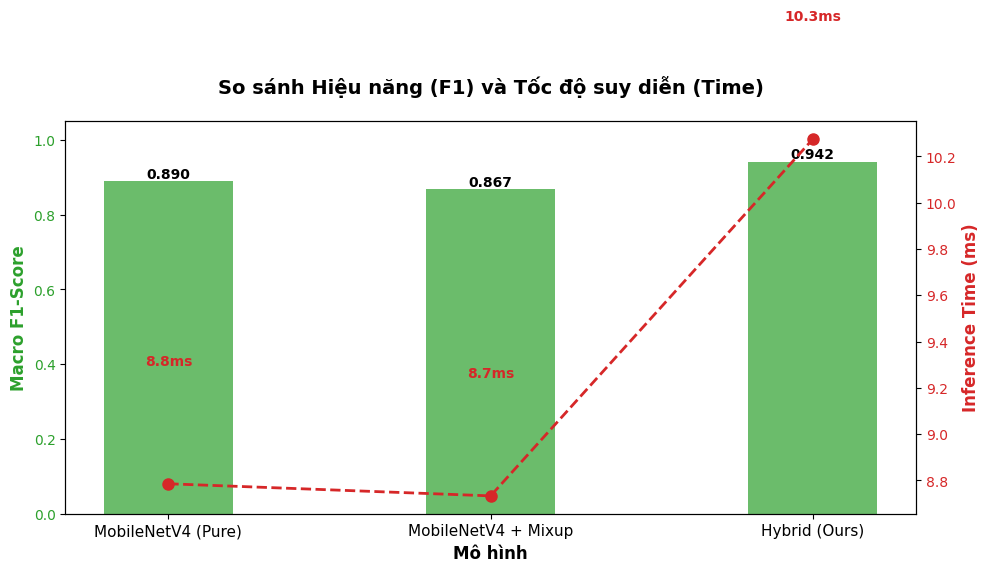

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
from sklearn.metrics import f1_score

def benchmark_and_plot_automated(models_dict, val_loader, config):
    """
    Hàm này tự động:
    1. Chạy đo đạc thực tế trên các model.
    2. Lưu kết quả vào biến.
    3. Vẽ biểu đồ từ chính số liệu thật đó.
    """
    device = config['device']
    dummy_input = torch.randn(1, 3, config['img_size'], config['img_size']).to(device)

    # Khởi tạo từ điển chứa dữ liệu thật
    data = {
        'names': [],
        'f1': [],
        'times': [],
        'params': []
    }

    print(" Đang tiến hành đo đạc và chấm điểm (Vui lòng đợi)...")

    for name, model in models_dict.items():
        model.eval()
        model.to(device)

        # --- 1. Đo số lượng tham số (Params) ---
        p = sum(p.numel() for p in model.parameters()) / 1e6
        data['params'].append(p)

        # --- 2. Đo tốc độ (Time) ---
        with torch.no_grad():
            # Warmup
            for _ in range(10): _ = model(dummy_input)
            # Đo thật (50 lần)
            start = time.time()
            for _ in range(50): _ = model(dummy_input)
            avg_time = (time.time() - start) / 50 * 1000 # đổi ra ms
        data['times'].append(avg_time)

        # --- 3. Đo Macro F1-Score ---
        all_preds, all_targets = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.to(device)
                # Xử lý output
                out = model(imgs)
                logits = out[0] if isinstance(out, tuple) else out

                all_preds.extend(logits.argmax(1).cpu().numpy())
                all_targets.extend(lbls.numpy())

        score = f1_score(all_targets, all_preds, average='macro')
        data['f1'].append(score)
        data['names'].append(name)

        print(f" Xong {name}: F1={score:.4f} | Time={avg_time:.2f}ms")

    # ==========================================
    # PHẦN VẼ BIỂU ĐỒ TỰ ĐỘNG (Dùng data thật)
    # ==========================================
    print("\n Đang vẽ biểu đồ so sánh...")
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Trục 1: Cột F1-Score
    x = np.arange(len(data['names']))
    width = 0.4

    color1 = '#2ca02c' # Màu xanh lá
    ax1.set_xlabel('Mô hình', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Macro F1-Score', color=color1, fontweight='bold', fontsize=12)
    bars = ax1.bar(x, data['f1'], width, color=color1, alpha=0.7, label='F1-Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(0, 1.05) # F1 max là 1
    ax1.set_xticks(x)
    ax1.set_xticklabels(data['names'], fontsize=11)

    # Ghi số lên đầu cột
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontweight='bold', color='black')

    # Trục 2: Đường cong Thời gian (Time)
    ax2 = ax1.twinx()
    color2 = '#d62728' # Màu đỏ
    ax2.set_ylabel('Inference Time (ms)', color=color2, fontweight='bold', fontsize=12)
    ax2.plot(x, data['times'], color=color2, marker='o', linewidth=2, markersize=8, linestyle='--', label='Latency (ms)')
    ax2.tick_params(axis='y', labelcolor=color2)

    # Ghi số thời gian bên cạnh điểm
    for i, txt in enumerate(data['times']):
        ax2.text(x[i], txt + 0.5, f'{txt:.1f}ms', color=color2, fontweight='bold', ha='center', va='bottom')

    plt.title('So sánh Hiệu năng (F1) và Tốc độ suy diễn (Time)', fontweight='bold', fontsize=14, pad=20)
    fig.tight_layout()
    plt.show()


benchmark_and_plot_automated(models_to_compare, val_loader, CONFIG)

### 6. Learning Curves
Biểu đồ thể hiện sự hội tụ của mô hình.

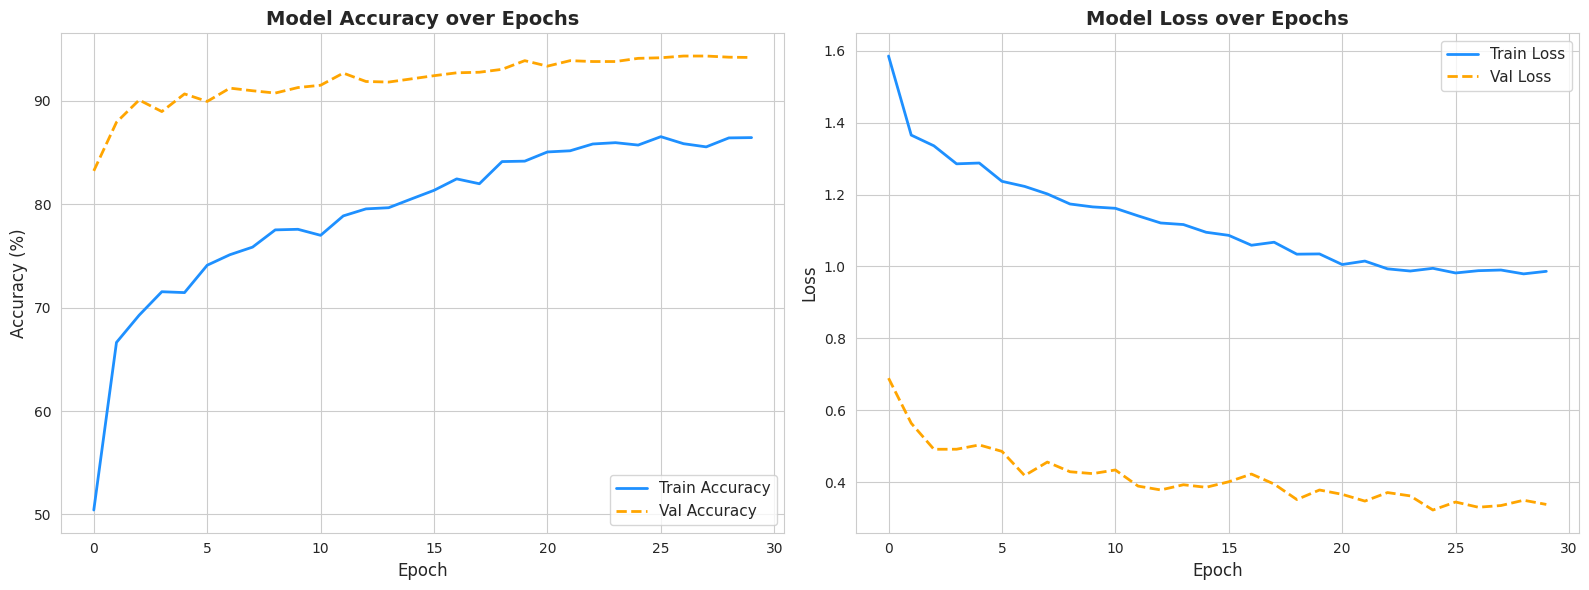

In [ ]:
sns.set_style("whitegrid")

def plot_training_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Accuracy Plot
    ax1.plot(history['train_acc'], label='Train Accuracy', color='dodgerblue', linewidth=2)
    ax1.plot(history['val_acc'], label='Val Accuracy', color='orange', linewidth=2, linestyle='--')
    ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy (%)', fontsize=12)
    ax1.legend(fontsize=11)

    # 2. Loss Plot
    ax2.plot(history['train_loss'], label='Train Loss', color='dodgerblue', linewidth=2)
    ax2.plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2, linestyle='--')
    ax2.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

plot_training_results(history)

### 7. Đánh giá chi tiết (Metrics)
Confusion Matrix, F1-Score.

✅ Đã load model tốt nhất từ: best_model_trashbox_sota.pth
⏳ Đang chạy đánh giá trên toàn bộ tập Validation...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   cardboard     0.9289    0.9193    0.9240       483
     e-waste     0.9493    0.9635    0.9563       602
       glass     0.9448    0.9466    0.9457       506
     medical     0.9688    0.9490    0.9588       392
       metal     0.9480    0.9498    0.9489       518
       paper     0.9171    0.9443    0.9305       539
     plastic     0.9538    0.9288    0.9412       534

    accuracy                         0.9435      3574
   macro avg     0.9444    0.9430    0.9436      3574
weighted avg     0.9437    0.9435    0.9435      3574



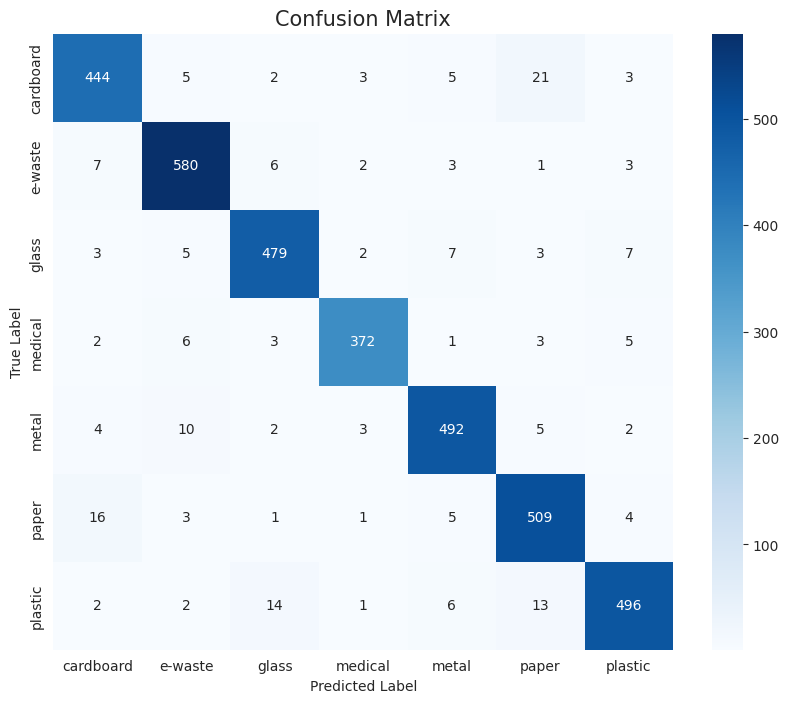

In [ ]:
# Load trọng số tốt nhất
best_model_path = "best_model_trashbox_sota.pth"
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    print(f"✅ Đã load model tốt nhất từ: {best_model_path}")
else:
    print("⚠️ Không tìm thấy file model, sử dụng trọng số hiện tại.")

model.eval()
all_preds, all_targets = [], []

print("⏳ Đang chạy đánh giá trên toàn bộ tập Validation...")
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(CONFIG['device'])

        logits, _ = model(inputs)

        _, preds = torch.max(logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

# In báo cáo
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# Vẽ Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix", fontsize=15)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

🔍 Đang tìm kiếm các ca dự đoán sai...


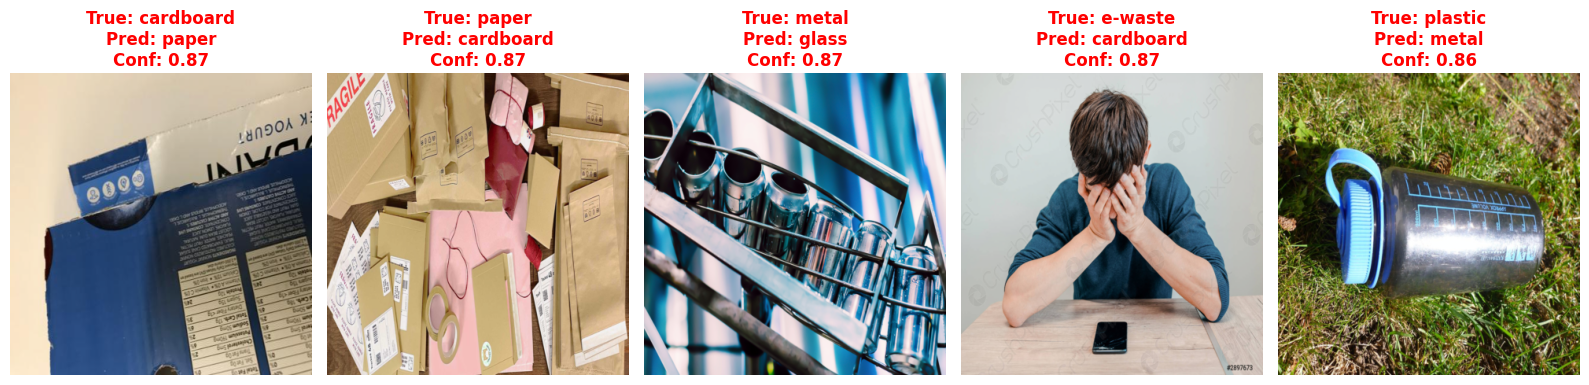

In [ ]:
def show_worst_mistakes(model, loader, top_k=5):
    model.eval()
    mistakes = [] # Lưu (conf, pred, true, image)

    print("🔍 Đang tìm kiếm các ca dự đoán sai...")
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(CONFIG['device']), targets.to(CONFIG['device'])

            logits, _ = model(inputs)

            probs = torch.softmax(logits, dim=1)
            conf, preds = torch.max(probs, 1)

            # Lọc các ca sai
            wrong_idx = (preds != targets).nonzero(as_tuple=True)[0]

            for idx in wrong_idx:
                img = inputs[idx].cpu()
                conf_val = conf[idx].item()
                pred_val = preds[idx].item()
                true_val = targets[idx].item()
                mistakes.append((conf_val, pred_val, true_val, img))

    # Sắp xếp theo độ tự tin (Sai mà càng tự tin thì càng nguy hiểm)
    mistakes.sort(key=lambda x: x[0], reverse=True)

    # Hiển thị
    num_show = min(len(mistakes), top_k)
    plt.figure(figsize=(16, 6))
    for i in range(num_show):
        conf, pred, true, img_t = mistakes[i]

        # Denormalize ảnh để hiển thị màu chuẩn
        img = img_t.permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = np.clip(img, 0, 1)

        plt.subplot(1, num_show, i+1)
        plt.imshow(img)
        plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}\nConf: {conf:.2f}",
                  color='red', fontweight='bold', fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_worst_mistakes(model, val_loader)

🚀 Đang test thử Core Engine cho Web App...
Prediction: medical (78.54%)
Time: 0.0133s


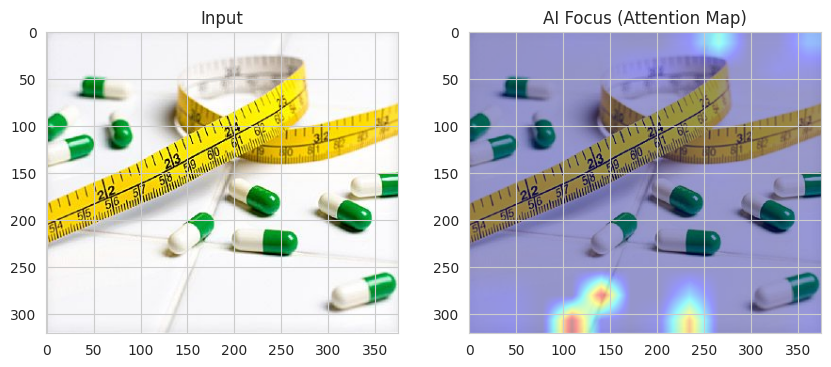

In [ ]:
import io
from PIL import Image

def predict_image_for_app(image_source, model, class_names, device=CONFIG['device']):
    """
    Hàm xử lý ảnh đầu vào (đường dẫn file hoặc PIL Image) và trả về kết quả
    kèm theo ảnh Visualization (Heatmap) để hiển thị trên App.

    Returns:
        dict: Chứa label, confidence, heatmap_image, time_taken...
    """
    model.eval()

    # 1. Load ảnh
    if isinstance(image_source, str):
        image = Image.open(image_source).convert('RGB')
    else:
        image = image_source.convert('RGB')

    # 2. Preprocess
    img_tensor = val_tfm(image).unsqueeze(0).to(device)

    # 3. Inference
    start_t = time.time()
    with torch.no_grad():
        logits, attn_weights = model(img_tensor)
        probs = torch.softmax(logits, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    inference_time = time.time() - start_t

    # 4. Generate Visualization (Heatmap)
    # Lấy trọng số Attention
    w = attn_weights[0].squeeze().cpu().numpy()
    grid_size = int(np.sqrt(w.shape[0]))
    w_2d = w.reshape(grid_size, grid_size)
    w_resized = cv2.resize(w_2d, (image.size[0], image.size[1]))

    # Tạo Heatmap màu
    w_resized = (w_resized - w_resized.min()) / (w_resized.max() - w_resized.min() + 1e-8)
    heatmap = cv2.applyColorMap(np.uint8(255 * w_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Phủ lên ảnh gốc (Overlay)
    img_np = np.array(image)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    # 5. Pack Result
    result = {
        "class_name": class_names[pred_idx.item()],
        "confidence": float(conf.item()),
        "inference_time": inference_time,
        "original_image": image,
        "heatmap_overlay": Image.fromarray(overlay), # Trả về dạng PIL Image để App dễ hiển thị
        "raw_probs": {name: float(prob) for name, prob in zip(class_names, probs[0].cpu().numpy())}
    }

    return result

print("🚀 Đang test thử Core Engine cho Web App...")
# Lấy đại 1 ảnh test
test_img_path = random.choice(val_ds.samples)[0]
res = predict_image_for_app(test_img_path, model, class_names)

print(f"Prediction: {res['class_name']} ({res['confidence']:.2%})")
print(f"Time: {res['inference_time']:.4f}s")
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(res['original_image']); plt.title("Input")
plt.subplot(1, 2, 2); plt.imshow(res['heatmap_overlay']); plt.title("AI Focus (Attention Map)")
plt.show()

### 8. Benchmark & XAI
Đo tốc độ xử lý và trực quan hóa lý do dự đoán (Heatmap).

⏱️ Đang đo tốc độ xử lý trên CUDA...
✅ Kết quả: 95.76 FPS (Frames Per Second)
   (Thời gian xử lý trung bình: 10.44 ms/ảnh)


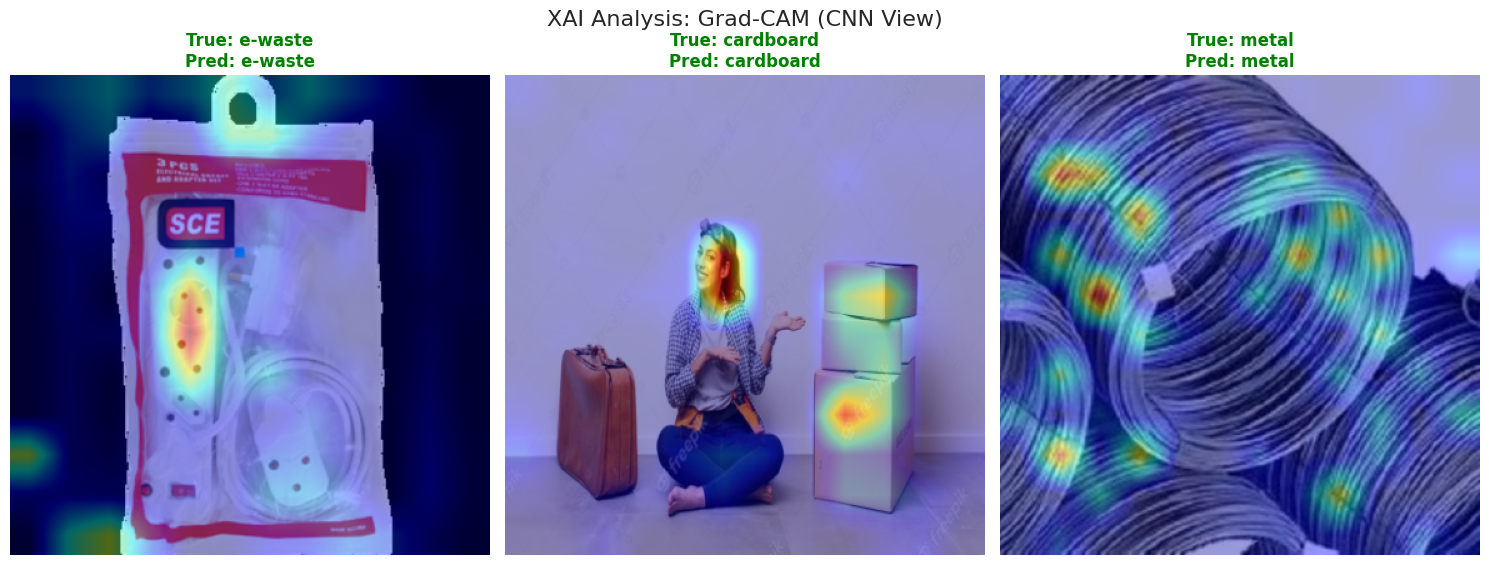

In [ ]:
import time
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# ==============================================================================
# 1. BENCHMARK INFERENCE SPEED
# ==============================================================================
def benchmark_model(model, device, img_size=384, num_runs=50):
    print(f"⏱️ Đang đo tốc độ xử lý trên {device.upper()}...")
    model.eval()
    dummy_input = torch.randn(1, 3, img_size, img_size).to(device)

    # Warmup
    for _ in range(10):
        with torch.no_grad():
            _ = model(dummy_input) # Tuple output được ignore

    # Đo thời gian
    torch.cuda.synchronize() if device == 'cuda' else None
    start_time = time.time()

    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(dummy_input)

    torch.cuda.synchronize() if device == 'cuda' else None
    end_time = time.time()

    fps = num_runs / (end_time - start_time)
    print(f"✅ Kết quả: {fps:.2f} FPS (Frames Per Second)")
    print(f"   (Thời gian xử lý trung bình: {(1/fps)*1000:.2f} ms/ảnh)")

benchmark_model(model, CONFIG['device'])

# ==============================================================================
# 2. ROBUST GRAD-CAM
# ==============================================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        # Hook vào layer
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.gradients = None
        self.activations = None

        # 1. Forward Pass
        # LƯU Ý QUAN TRỌNG: Model trả về (logits, attn_weights)
        logits, _ = self.model(x)

        # 2. Backward Pass
        self.model.zero_grad()
        target_index = logits.argmax()

        # Chỉ backward trên logits
        logits[0, target_index].backward()

        if self.gradients is None:
            raise ValueError("Không bắt được Gradient! Layer hook có thể sai vị trí.")

        # 3. Tính toán Heatmap
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activation = self.activations[0].detach()

        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activation, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0) # ReLU

        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap) # Normalize

        return heatmap, target_index.item()

# ==============================================================================
# 3. VISUALIZATION DEMO
# ==============================================================================
# Hook vào proj (Feature map trước khi vào Transformer)
grad_cam = GradCAM(model, model.proj)

indices = random.sample(range(len(val_ds)), 3) # Lấy 3 ảnh demo nhanh

plt.figure(figsize=(15, 6))
plt.suptitle("XAI Analysis: Grad-CAM (CNN View)", fontsize=16)

for i, idx in enumerate(indices):
    img_t, label_idx = val_ds[idx]
    input_tensor = img_t.unsqueeze(0).to(CONFIG['device'])
    input_tensor.requires_grad = True

    heatmap, pred_idx = grad_cam(input_tensor)

    # Denormalize Image
    img_np = img_t.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = np.clip(img_np, 0, 1)

    # Overlay Heatmap
    heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    heatmap_c = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_c = cv2.cvtColor(heatmap_c, cv2.COLOR_BGR2RGB) / 255.0
    overlay = heatmap_c * 0.4 + img_np * 0.6

    # Plot
    plt.subplot(1, 3, i + 1)
    plt.imshow(overlay)
    color = 'green' if pred_idx == label_idx else 'red'
    plt.title(f"True: {class_names[label_idx]}\nPred: {class_names[pred_idx]}", color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

✅ Đã đồng bộ nhãn hoàn tất. Số lượng ảnh hợp lệ: 1793
🚀 Đang chạy Test...

🏆 TEST ACCURACY: 94.14%
------------------------------------------------------------
              precision    recall  f1-score   support

   cardboard     0.9298    0.9298    0.9298       242
     e-waste     0.9486    0.9768    0.9625       302
       glass     0.9484    0.9409    0.9447       254
     medical     0.9588    0.9442    0.9514       197
       metal     0.9344    0.9308    0.9326       260
       paper     0.9301    0.9370    0.9336       270
     plastic     0.9430    0.9254    0.9341       268

    accuracy                         0.9414      1793
   macro avg     0.9419    0.9407    0.9412      1793
weighted avg     0.9415    0.9414    0.9414      1793



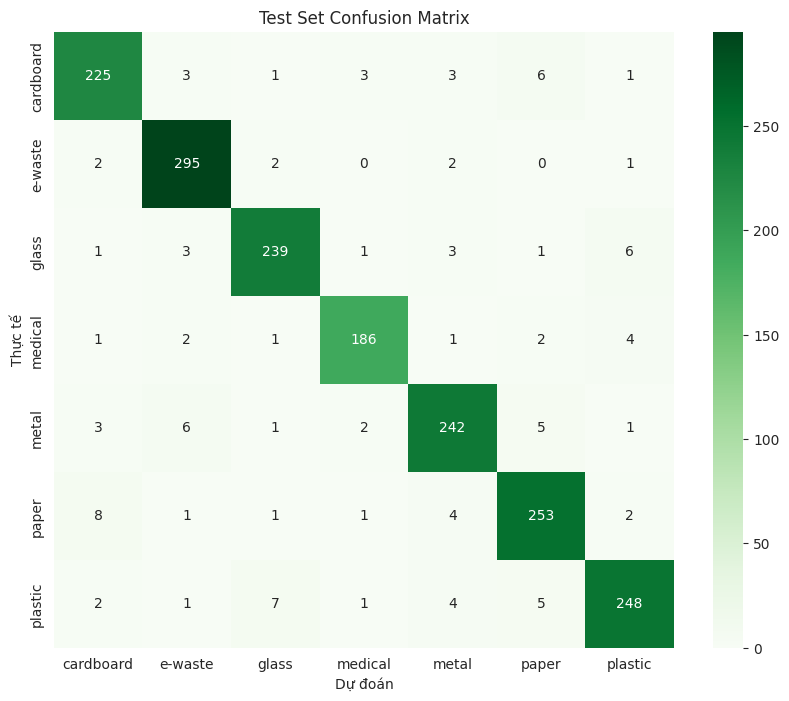

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets

# 1. SETUP DATA & FORCE LABEL MATCHING
ROOT_TEST = '/content/temp_data/val/test'

# Khởi tạo dataset tạm
test_ds = datasets.ImageFolder(ROOT_TEST, transform=val_tfm)

# --- QUAN TRỌNG: ĐỒNG BỘ LABEL (Re-align targets) ---
# Đảm bảo tập Test dùng đúng index của tập Train, bất kể folder test sắp xếp thế nào
if 'train_ds' in globals():
    train_dict = train_ds.class_to_idx
    new_samples = []
    valid_count = 0

    # Duyệt qua từng ảnh test và gán lại index chuẩn từ tập train
    for path, _ in test_ds.samples:
        class_name = os.path.basename(os.path.dirname(path)) # Lấy tên folder cha
        if class_name in train_dict:
            new_samples.append((path, train_dict[class_name]))
            valid_count += 1

    # Cập nhật lại metadata cho test_ds
    test_ds.samples = new_samples
    test_ds.targets = [s[1] for s in new_samples]
    test_ds.class_to_idx = train_dict
    test_ds.classes = list(train_dict.keys())
    print(f"✅ Đã đồng bộ nhãn hoàn tất. Số lượng ảnh hợp lệ: {valid_count}")
else:
    print("⚠️ Cảnh báo: Không tìm thấy tập Train để đồng bộ nhãn.")

test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)

# 2. LOAD MODEL & INFERENCE
model.load_state_dict(torch.load("best_model_trashbox_sota.pth"))
model.eval()

all_preds, all_targets = [], []
print("🚀 Đang chạy Test...")

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(CONFIG['device'])

        # Unpack tuple (logits, attn_weights) - Chỉ lấy logits
        logits, _ = model(inputs)
        _, preds = torch.max(logits, 1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

# 3. REPORT
acc = accuracy_score(all_targets, all_preds)
print(f"\n🏆 TEST ACCURACY: {acc*100:.2f}%")
print("-" * 60)
print(classification_report(all_targets, all_preds, target_names=test_ds.classes, digits=4))

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(all_targets, all_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=test_ds.classes, yticklabels=test_ds.classes)
plt.title('Test Set Confusion Matrix')
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán'); plt.show()

# LIVE DEMO

In [ ]:
!pip install gradio timm

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.5 MB/s eta 0:00:00


In [ ]:
import gradio as gr
import torch
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F
from ultralytics import YOLO

# (Giữ nguyên phần load model cũ, đảm bảo model đã được load vào biến 'model')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classes = ['cardboard', 'e-waste', 'glass', 'medical', 'metal', 'paper', 'plastic']
img_size = 384

# Transform cho model Hybrid
tfms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Sử dụng YOLOv8 nano đã pre-train
detector = YOLO('yolov8n.pt')

# --- 3. HÀM XỬ LÝ THÔNG MINH ---
def smart_predict(image_pil):
    if image_pil is None: return None, "Chưa có ảnh."

    # A. Giai đoạn 1: Dùng YOLO tìm vật thể
    # conf=0.25: Chỉ lấy vật thể có độ tin cậy > 25%
    results = detector(image_pil, conf=0.25, verbose=False)

    # Chuyển ảnh sang OpenCV để vẽ
    img_cv = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
    original_h, original_w = img_cv.shape[:2]

    detected_objects = []

    # Nếu YOLO không tìm thấy gì, ta sẽ classify toàn bộ ảnh (fallback)
    boxes = results[0].boxes
    if len(boxes) == 0:
        boxes_data = [[0, 0, original_w, original_h]] # Toàn bộ ảnh
    else:
        boxes_data = boxes.xyxy.cpu().numpy()

    # B. Giai đoạn 2: Duyệt qua từng vật thể tìm được
    for box in boxes_data:
        x1, y1, x2, y2 = map(int, box)

        # Crop ảnh vật thể
        crop_obj = image_pil.crop((x1, y1, x2, y2))

        # Đưa vào Model Hybrid của bạn
        crop_tensor = tfms(crop_obj).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, _ = model(crop_tensor)
            probs = F.softmax(logits, dim=1)
            conf, pred_idx = torch.max(probs, 1)

        label = classes[pred_idx.item()]
        score = conf.item()

        detected_objects.append(f"- {label.upper()} ({score:.1%})")

        # Vẽ khung và nhãn lên ảnh
        # Màu sắc khung: Đỏ (nguy hại), Xanh lá (tái chế), Vàng (khác)
        color = (0, 255, 255) # Mặc định Vàng
        if label in ['medical', 'e-waste']: color = (0, 0, 255) # Đỏ
        elif label in ['glass', 'paper', 'cardboard', 'metal']: color = (0, 255, 0) # Xanh lá

        cv2.rectangle(img_cv, (x1, y1), (x2, y2), color, 2)

        # Vẽ text nền đen cho dễ đọc
        text = f"{label} {score:.0%}"
        (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(img_cv, (x1, y1 - 20), (x1 + w, y1), color, -1)
        cv2.putText(img_cv, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    # Chuyển lại sang PIL để hiển thị
    final_img = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    report = "Đã phát hiện:\n" + "\n".join(detected_objects)
    return final_img, report

with gr.Blocks() as demo:
    gr.Markdown("### Smart Trash AI (Auto-Detection)")
    gr.Markdown("Hệ thống tự động tìm vật thể (YOLO) và phân loại chất liệu (Hybrid Model).")

    with gr.Row():
        inp = gr.Image(type="pil", label="Tải ảnh lên")
        btn = gr.Button(" Quét Tự Động", variant="primary")

    with gr.Row():
        out_img = gr.Image(label="Kết quả AI nhìn thấy")
        out_txt = gr.Textbox(label="Danh sách rác")

    btn.click(smart_predict, inputs=inp, outputs=[out_img, out_txt])

demo.launch(share=True, debug=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4f18a64665bafdecb0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO
import timm
import math

# --- 1. CẤU HÌNH (CONFIG) ---
# Phải khớp với config lúc train trong notebook
CONFIG = {
    "num_classes": 7,
    "img_size": 384,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "backbone_name": "mobilenetv4_conv_medium.e500_r256_in1k",
    "embed_dim": 256,
    "use_arcface": False, # Chú ý: Nếu lúc train để True thì sửa thành True
    "arcface_s": 30.0,
    "arcface_m": 0.50,
}

device = torch.device(CONFIG['device'])
classes = ['cardboard', 'e-waste', 'glass', 'medical', 'metal', 'paper', 'plastic']

# --- 2. ĐỊNH NGHĨA MODEL ---
class ArcMarginProduct(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50, easy_margin=False):
        super(ArcMarginProduct, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.easy_margin = easy_margin
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.att = nn.Sequential(
            nn.Linear(dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        weights = F.softmax(self.att(x), dim=1)
        context = torch.sum(x * weights, dim=1)
        return context, weights

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)), nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim), nn.Dropout(drop)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class HybridTrashModel(nn.Module):
    def __init__(self, num_classes, backbone_name=CONFIG['backbone_name'], embed_dim=CONFIG['embed_dim'], use_arcface=CONFIG['use_arcface']):
        super().__init__()
        self.use_arcface = use_arcface
        # Backbone
        self.backbone = timm.create_model(backbone_name, pretrained=False, features_only=True) # pretrained=False vì sẽ load .pth
        last_channel = self.backbone.feature_info[-1]['num_chs']
        # Bridge
        self.proj = nn.Conv2d(last_channel, embed_dim, kernel_size=1)
        # Transformer
        self.transformer = nn.Sequential(
            TransformerBlock(embed_dim, num_heads=4, drop=0.1),
            TransformerBlock(embed_dim, num_heads=4, drop=0.1)
        )
        # Attention Pooling
        self.pool = AttentionPooling(embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        # Head
        if self.use_arcface:
            self.head = ArcMarginProduct(embed_dim, num_classes, s=CONFIG['arcface_s'], m=CONFIG['arcface_m'])
        else:
            self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x, labels=None):
        features = self.backbone(x)[-1]
        x = self.proj(features)
        x = x.flatten(2).transpose(1, 2)
        x = self.transformer(x)
        x = self.norm(x)
        x_pool, attn_weights = self.pool(x)
        if self.use_arcface and labels is not None:
            logits = self.head(x_pool, labels)
        else:
            logits = self.head(x_pool)
        return logits, attn_weights

# --- 3. KHỞI TẠO VÀ LOAD MODEL ---
print("Đang khởi tạo model...")
model = HybridTrashModel(num_classes=CONFIG['num_classes']).to(device)

# >>> QUAN TRỌNG: Thay đường dẫn file .pth của bạn vào đây <<<
pth_path = "best_model_trashbox_sota.pth"  # Ví dụ: '/content/drive/MyDrive/best.pth'

if pth_path:
    try:
        state_dict = torch.load(pth_path, map_location=device)
        model.load_state_dict(state_dict)
        print(f"Đã load weights thành công từ: {pth_path}")
    except Exception as e:
        print(f"Lỗi load file .pth: {e}")
        print("Đang chạy với model chưa train (random weights)!")

model.eval() # Chuyển sang chế độ đánh giá

# --- 4. CÁC THÀNH PHẦN CÒN LẠI (Transform & YOLO) ---
tfms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

detector = YOLO('yolov8n.pt')

# --- 5. HÀM DỰ ĐOÁN (Giữ nguyên logic của bạn) ---
def smart_predict(image_pil):
    if image_pil is None: return None, "Chưa có ảnh."

    # A. Giai đoạn 1: YOLO
    results = detector(image_pil, conf=0.25, verbose=False)
    img_cv = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
    original_h, original_w = img_cv.shape[:2]
    detected_objects = []

    boxes = results[0].boxes
    if len(boxes) == 0:
        boxes_data = [[0, 0, original_w, original_h]] # Fallback: Toàn bộ ảnh
    else:
        boxes_data = boxes.xyxy.cpu().numpy()

    # B. Giai đoạn 2: Hybrid Model
    for box in boxes_data:
        x1, y1, x2, y2 = map(int, box)
        # Giới hạn tọa độ trong ảnh
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(original_w, x2), min(original_h, y2)

        if x2 <= x1 or y2 <= y1: continue

        crop_obj = image_pil.crop((x1, y1, x2, y2))
        crop_tensor = tfms(crop_obj).unsqueeze(0).to(device)

        with torch.no_grad():
            # Model Hybrid trả về (logits, weights)
            logits, _ = model(crop_tensor)
            probs = F.softmax(logits, dim=1)
            conf, pred_idx = torch.max(probs, 1)

        label = classes[pred_idx.item()]
        score = conf.item()

        detected_objects.append(f"- {label.upper()} ({score:.1%})")

        # Vẽ
        color = (0, 255, 255)
        if label in ['medical', 'e-waste']: color = (0, 0, 255)
        elif label in ['glass', 'paper', 'cardboard', 'metal']: color = (0, 255, 0)

        cv2.rectangle(img_cv, (x1, y1), (x2, y2), color, 2)
        text = f"{label} {score:.0%}"
        (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(img_cv, (x1, y1 - 20), (x1 + w, y1), color, -1)
        cv2.putText(img_cv, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    final_img = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    report = "Đã phát hiện:\n" + "\n".join(detected_objects) if detected_objects else "Không nhận diện được vật thể nào."
    return final_img, report

# --- 6. GIAO DIỆN GRADIO ---
with gr.Blocks() as demo:
    gr.Markdown("### Smart Trash AI (Auto-Detection)")
    gr.Markdown(f"Model Hybrid được load từ: {pth_path}")

    with gr.Row():
        inp = gr.Image(type="pil", label="Tải ảnh lên")
        btn = gr.Button("Quét Tự Động", variant="primary")

    with gr.Row():
        out_img = gr.Image(label="Kết quả")
        out_txt = gr.Textbox(label="Chi tiết")

    btn.click(smart_predict, inputs=inp, outputs=[out_img, out_txt])

demo.launch(share=True, debug=True)

Đang khởi tạo model...
Đã load weights thành công từ: best_model_trashbox_sota.pth
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://9244cd0eeaf1d04762.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",